# Reporte 03: Fuerza Capilar (Grado Nodal) y Nodos de Transferencia Intermodal ($FC$)

## 1. Justificación Teórica
El presente indicador evalúa la **Fuerza Capilar** de la red de transporte, definida topológicamente como el grado nodal ($k$) de cada estación. Este indicador cuantifica el nivel de convergencia de flujos y la capacidad de un nodo para actuar como punto de transferencia intermodal. 

Para obtener una radiografía urbana realista y mitigar la inflación geométrica, el modelo divide la Fuerza Capilar en dos dimensiones analíticas:

**A. Fuerza Capilar Geográfica (Macro-Hubs):**
Agrupa topológicamente estaciones físicamente colindantes (radio de tolerancia de 100m) en un subgrafo $H$. Consolida los flujos de sus estaciones constituyentes eliminando las duplicidades. Representa el fenómeno urbano del transbordo físico (ej. CETRAMs):

$$FC_{H} = \sum_{j \in H} \left( k_{in}(j) + k_{out}(j) \right) - \text{Aristas Internas}$$

**B. Fuerza Capilar Matemática / Estricta (Por Estación Individual):**
Calcula el grado de entrada y salida de un nodo topológico $i$, aplicando un filtro de frontera espacial (radio de 25m) para capturar únicamente los vectores de flujo. Representa la centralidad pura del nodo en el grafo:

$$FC_i = k_{in}(i)_{frontera} + k_{out}(i)_{frontera}$$

In [22]:
# ==========================================
# 2. Inicialización del Entorno y Librerías
# ==========================================
%load_ext autoreload
%autoreload 2
%matplotlib inline 

import sys
import os
import re
import ast
import folium
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Silenciar advertencias futuras para un reporte limpio
warnings.filterwarnings('ignore', category=FutureWarning)

# Asegurar que Jupyter encuentra la carpeta raíz del proyecto
proyecto_path = os.path.abspath('..')
if proyecto_path not in sys.path:
    sys.path.append(proyecto_path)

from src.infrastructure.go_client.client import fetch_full_network
from src.api.schemas.schemas import GeoJSONTransportSchema
from src.core.services.graph_builder import build_and_plot_network
from src.core.algorithms.topological_indicators import TopologicalIndicatorAnalyzer

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
# ==========================================
# 3. Descarga de Red y Construcción del Grafo
# ==========================================
print("📥 Descargando red de transporte...")
raw_data = await fetch_full_network()

print("⚙️ Construyendo Grafo Dirigido VFT...")
validated_payload = GeoJSONTransportSchema(**raw_data)

plt.ioff() 
G = build_and_plot_network(validated_payload)
plt.close('all')
plt.ion()

print(f"✅ Grafo construido: {G.number_of_nodes()} nodos topológicos.")

📥 Descargando red de transporte...
2026-04-08 17:25:12 | INFO     | VFT_Model | Construyendo el puente hacia el módulo espacial de Go...
2026-04-08 17:25:12 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonEstacion
2026-04-08 17:25:12 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonLinea
2026-04-08 17:25:12 | INFO     | VFT_Model | Red extraída: 22785 entidades espaciales listas para VFT.
⚙️ Construyendo Grafo Dirigido VFT...
2026-04-08 17:25:12 | INFO     | VFT_Model | Iniciando la construcción del Grafo VFT...
2026-04-08 17:25:13 | INFO     | VFT_Model | Grafo Dirigido construido: 101621 Nodos topológicos y 93816 Segmentos de flujo.
2026-04-08 17:25:13 | INFO     | VFT_Model | Llamando al Motor de Impedancia VFT...
2026-04-08 17:25:13 | INFO     | VFT_Model | Iniciando inyección de motor de impendancia sobre VFT:
2026-04-08 17:25:13 | INFO     | VFT_Model | Impedancia aplicada exitosa

## 4. Ejecución del Motor Topológico
A continuación, instanciamos el analizador sobre el grafo dirigido (`G`) y calculamos ambos escenarios de fuerza capilar.

In [24]:
# ==========================================
# 4. Cálculo de Indicadores Capilares
# ==========================================
analizador_topologico = TopologicalIndicatorAnalyzer(G)

# Estos dos DataFrames alimentarán TODO el resto del notebook
df_estricto = analizador_topologico.calculate_capillary_strength(snap_tolerance_m=25.0)
df_macro_hubs = analizador_topologico.calculate_geo_capillary_strength(tolerance_m=100.0, snap_tolerance_m=25.0)

print(f"📊 Nodos individuales procesados: {len(df_estricto)}")
print(f"📊 Macro-Hubs consolidados: {len(df_macro_hubs)}")

📊 Nodos individuales procesados: 11115
📊 Macro-Hubs consolidados: 3800


---
## 5. Análisis Geográfico: Macro-Hubs Intermodales
Este enfoque revela la infraestructura física de transbordo. Al agrupar estaciones cercanas, emergen los grandes polígonos de movilidad de la ciudad.

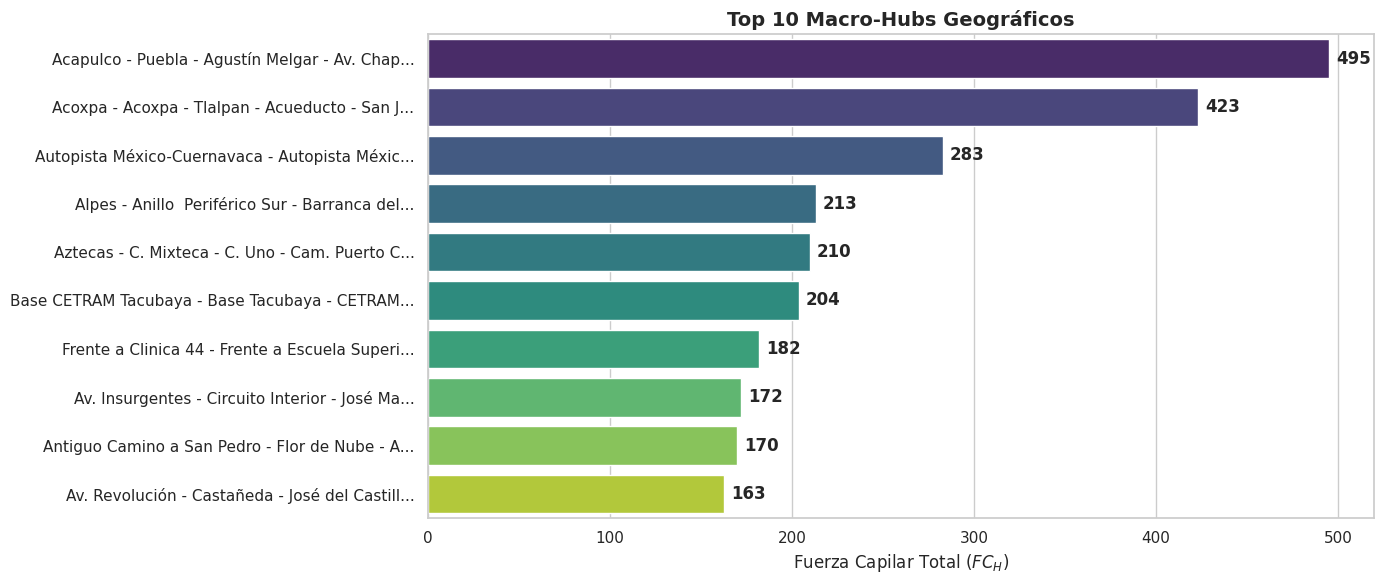

In [25]:
# --- Gráfica de Barras ---
top_10_hubs = df_macro_hubs.head(10).copy()
top_10_hubs['Macro_Hub_Corto'] = top_10_hubs['Macro_Hub'].apply(lambda x: x[:45] + '...' if len(x) > 45 else x)

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=top_10_hubs, 
    x='Fuerza_Capilar_Total', 
    y='Macro_Hub_Corto', 
    palette='viridis', 
    ax=ax
)

ax.set_title('Top 10 Macro-Hubs Geográficos', fontsize=14, fontweight='bold')
ax.set_xlabel('Fuerza Capilar Total ($FC_H$)')
ax.set_ylabel('')

for i in ax.containers: 
    ax.bar_label(i, padding=5, fontweight='bold')

# 5. Ajustar y forzar el renderizado en Jupyter
plt.tight_layout()
display(fig)
plt.close(fig)

In [26]:
# --- Mapa Interactivo ---
mapa_geo = folium.Map(location=[19.4326, -99.1332], zoom_start=11, tiles="CartoDB positron")

# Para mapear los Hubs, buscamos sus estaciones constituyentes en el df_estricto
for _, hub in top_10_hubs.iterrows():
    nodos_hub = df_estricto[df_estricto['Estacion'].apply(lambda x: x in hub['Macro_Hub'])]
    
    for _, nodo in nodos_hub.iterrows():
        try:
            lon, lat = ast.literal_eval(nodo['Nodo_ID'])
            folium.CircleMarker(
                location=(lat, lon), radius=max(hub['Fuerza_Capilar_Total']*0.1, 5),
                color="#2A7686", fill=True, fill_color="#2A7686", fill_opacity=0.6,
                popup=f"<b>Macro-Hub:</b> {hub['Macro_Hub_Corto']}<br><b>FC Geográfica:</b> {hub['Fuerza_Capilar_Total']}"
            ).add_to(mapa_geo)
        except: pass

display(mapa_geo)

---
## 6. Análisis Matemático: Centralidad Estricta
Evalúa la convergencia puntual sin agrupaciones, detectando puntos específicos (coordenadas únicas) que soportan una gran carga de vectores vehiculares.

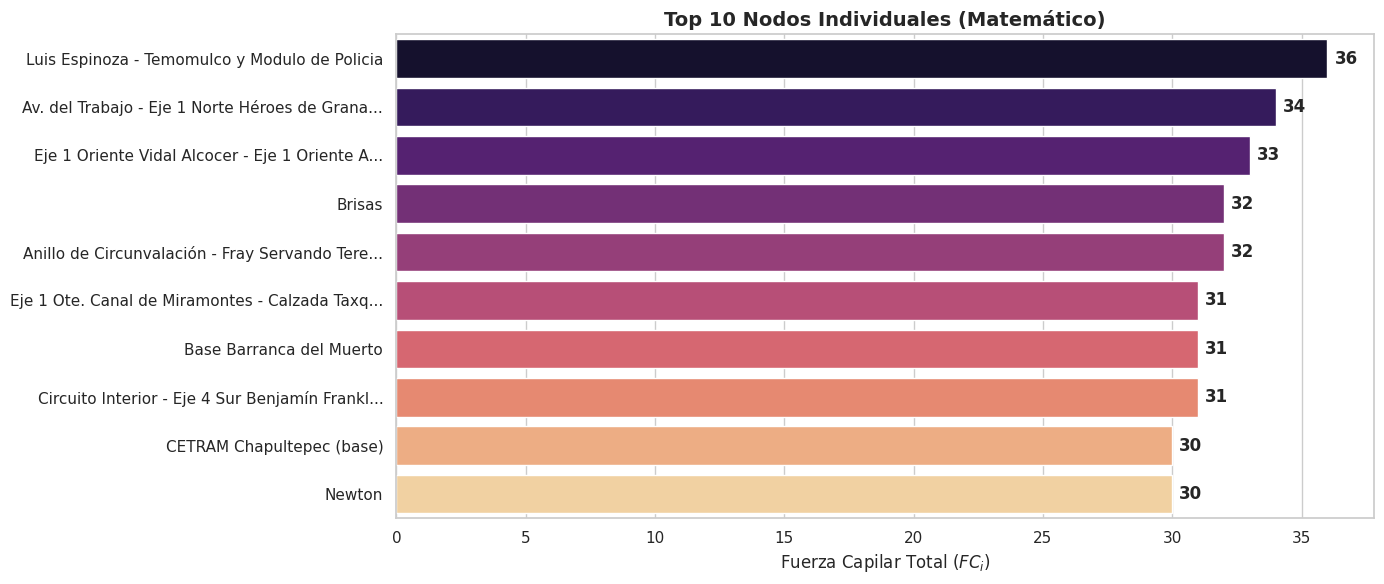

In [27]:
# --- Gráfica de Barras ---
top_10_nodos = df_estricto.head(10).copy()

top_10_nodos['Estacion_Corta'] = top_10_nodos['Estacion'].apply(
    lambda x: x[:45] + '...' if len(x) > 45 else x
)
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=top_10_nodos, 
    x='Fuerza_Capilar_Total', 
    y='Estacion_Corta', 
    palette='magma', 
    ax=ax
)

ax.set_title('Top 10 Nodos Individuales (Matemático)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fuerza Capilar Total ($FC_i$)')
ax.set_ylabel('')

for i in ax.containers: 
    ax.bar_label(i, padding=5, fontweight='bold')

plt.tight_layout()
display(fig)
plt.close(fig)

In [28]:

# --- Mapa Interactivo ---
mapa_math = folium.Map(location=[19.4326, -99.1332], zoom_start=11, tiles="CartoDB positron")

for _, row in top_10_nodos.iterrows():
    try:
        lon, lat = ast.literal_eval(row['Nodo_ID'])
        folium.CircleMarker(
            location=(lat, lon), radius=max(row['Fuerza_Capilar_Total']*0.2, 5),
            color="#C73E5C", fill=True, fill_color="#C73E5C", fill_opacity=0.7,
            popup=f"<b>Nodo:</b> {row['Estacion']}<br><b>FC Matemática:</b> {row['Fuerza_Capilar_Total']}"
        ).add_to(mapa_math)
    except: pass

display(mapa_math)

---
### 6.1. Distribución de la Capilaridad Matemática (Ley de Potencias)
La topología de la red sigue una distribución de **Scale-Free Network** (Ley de Potencias). 
¿Por qué ocurre esto? En los sistemas de transporte reales, la inmensa mayoría de las paradas actúan como nodos de paso simples (1 conexión de entrada y 1 de salida = FC de 2). Por el contrario, un grupo extremadamente reducido de nodos actúa como absorbedores masivos de rutas (decenas de conexiones). Esta desigualdad genera la curva logarítmica descendente que vemos a continuación.

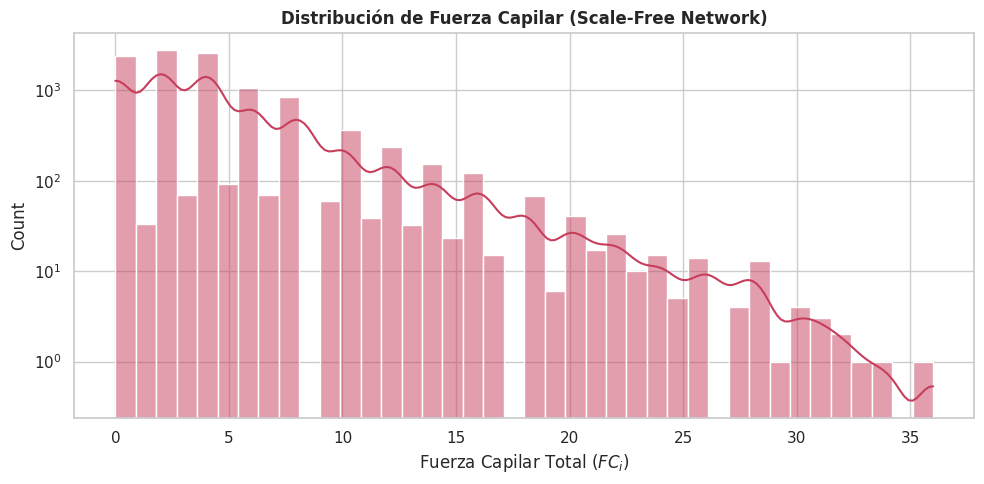

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    df_estricto['Fuerza_Capilar_Total'], 
    bins=40, 
    kde=True, 
    color='#C73E5C', 
    ax=ax
)
ax.set_title('Distribución de Fuerza Capilar (Scale-Free Network)', fontweight='bold')
ax.set_xlabel('Fuerza Capilar Total ($FC_i$)')
ax.set_yscale('log')

plt.tight_layout()
display(fig)
plt.close(fig)

In [30]:
# --- Tabla Demostrativa del Fenómeno ---
print("Ejemplo de la polarización en la red:")
df_ejemplo = pd.concat([df_estricto.head(2), df_estricto[df_estricto['Fuerza_Capilar_Total'] == 2].tail(2)])
display(df_ejemplo[['Estacion', 'Sistemas_Integrados', 'Fuerza_Capilar_Total']])

Ejemplo de la polarización en la red:


,Estacion,Sistemas_Integrados,Fuerza_Capilar_Total
7264,Luis Espinoza - Temomulco y Modulo de Policia,[RTP],36
1257,Av. del Trabajo - Eje 1 Norte Héroes de Granad...,[RTP],34
6466,Ignacio Allende,[RTP],2
6402,Honorable Congreso de la Unión - Platino,[RTP],2


---
## 7. Anexo: Diagnóstico Especulativo para Ruta Anillar (Periférico)
Este apartado aísla los nodos y Macro-Hubs que cruzan o se nombran "Periférico". Se divide en la perspectiva Matemática y Geográfica para identificar anclajes potenciales.

In [31]:
# Expresión regular para atrapar variantes de la palabra
patron = re.compile(r'perif[eé]rico', re.IGNORECASE)

df_peri_math = df_estricto[df_estricto['Estacion'].str.contains(patron, na=False)].sort_values(by='Fuerza_Capilar_Total', ascending=False)
df_peri_geo = df_macro_hubs[df_macro_hubs['Macro_Hub'].str.contains(patron, na=False)].sort_values(by='Fuerza_Capilar_Total', ascending=False)

### 7.1. Eje Periférico: Perspectiva Geográfica (Macro-Hubs)
Muestra los polígonos de transferencia más fuertes a lo largo de la vialidad.

In [32]:
print("Ejemplo de Estaciones Periféricas en la Red Geográfica:")
df_peri_geo.head(5)

Ejemplo de Estaciones Periféricas en la Red Geográfica:


,Macro_Hub,Sistemas_Integrados,Detalle_Estaciones,Estaciones_Agrupadas,Conexiones_Entrada,Conexiones_Salida,Fuerza_Capilar_Total
227,Alpes - Anillo Periférico Sur - Barranca del ...,"[CORREDOR_CONCESIONADO, RTP]","{'CORREDOR_CONCESIONADO': ['Alpes', 'Av. Revol...",21,106,107,213
345,Anillo Periférico Canal de Garay - Constitució...,"[CORREDOR_CONCESIONADO, METROBUS, RTP]",{'RTP': ['Anillo Periférico Canal de Garay - C...,8,59,59,118
293,Anillo Periférico - Anillo Periférico Sur - Al...,"[CORREDOR_CONCESIONADO, RTP]","{'RTP': ['Anillo Periférico', 'Anillo Periféri...",10,54,54,108
945,Av. San Lorenzo - Av. Tláhuac - Av. Tláhuac - ...,"[CORREDOR_CONCESIONADO, METRO, RTP, TROLEBUS]","{'RTP': ['Av. Tláhuac', 'Av. Tláhuac - Anillo ...",9,38,38,76
306,Anillo Periférico Blvd. Adolfo Ruiz Cortines -...,"[CORREDOR_CONCESIONADO, RTP]",{'RTP': ['Anillo Periférico Blvd. Adolfo Ruiz ...,9,32,32,64


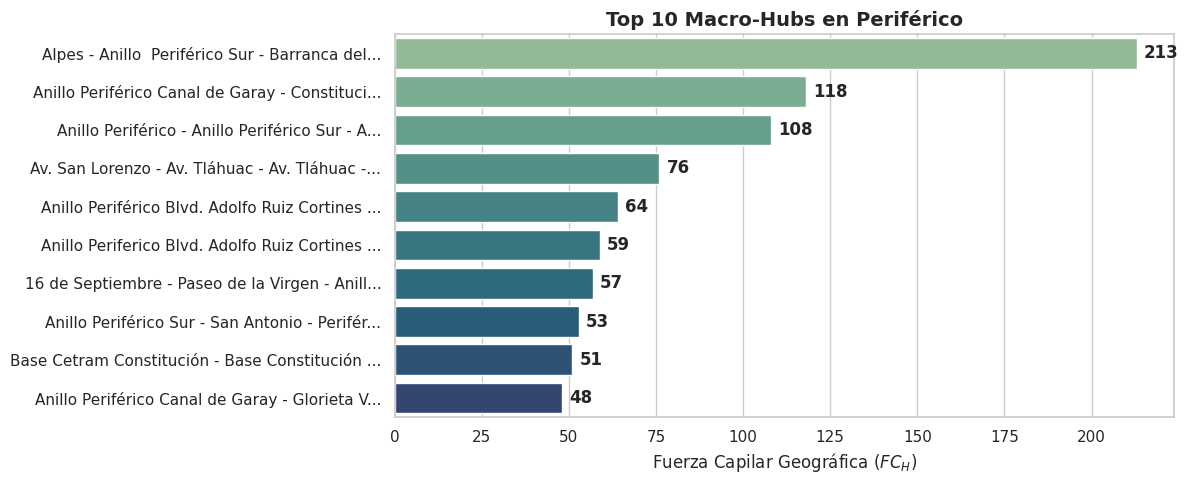

In [33]:
# --- Datos ---
top_peri_geo = df_peri_geo.head(10).copy()
top_peri_geo['Macro_Hub_Corto'] = top_peri_geo['Macro_Hub'].apply(
    lambda x: x[:45] + '...' if len(x) > 45 else x
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=top_peri_geo,
    x='Fuerza_Capilar_Total', 
    y='Macro_Hub_Corto',
    palette='crest',
    ax=ax
)

ax.set_title('Top 10 Macro-Hubs en Periférico', fontsize=14, fontweight='bold')
ax.set_xlabel('Fuerza Capilar Geográfica ($FC_H$)')
ax.set_ylabel('')

for i in ax.containers:
    ax.bar_label(i, padding=5, fontweight='bold')
    
plt.tight_layout()
display(fig)
plt.close(fig)

In [34]:
# Mapa
mapa_peri_geo = folium.Map(location=[19.3500, -99.1900], zoom_start=11, tiles="CartoDB positron")
for _, hub in top_peri_geo.iterrows():
    nodos_hub = df_estricto[df_estricto['Estacion'].apply(lambda x: x in hub['Macro_Hub'])]
    for _, nodo in nodos_hub.iterrows():
        try:
            lon, lat = ast.literal_eval(nodo['Nodo_ID'])
            folium.CircleMarker(
                location=(lat, lon), radius=max(hub['Fuerza_Capilar_Total']*0.2, 6),
                color="#1B4F72", fill=True, fill_opacity=0.7, popup=f"Hub: {hub['Macro_Hub_Corto']}"
            ).add_to(mapa_peri_geo)
        except: pass
display(mapa_peri_geo)

### 7.2. Eje Periférico: Perspectiva Matemática (Nodos Individuales)
Muestra las coordenadas exactas de mayor tensión vehicular intermodal sobre el anillo.

In [35]:
df_peri_math.head(5)

,Nodo_ID,Estacion,Sistemas_Integrados,Detalle_Estaciones,Estaciones_Agrupadas,Conexiones_Entrada,Conexiones_Salida,Fuerza_Capilar_Total
8538,"(-99.19147, 19.36391)",Periférico - Barranca del Muerto,[CORREDOR_CONCESIONADO],{'CORREDOR_CONCESIONADO': ['Periférico - Barra...,1,11,11,22
509,"(-99.19096, 19.36316)",Anillo Periférico Sur - Barranca del Muerto,[RTP],{'RTP': ['Anillo Periférico Sur - Barranca de...,1,11,11,22
690,"(-99.19144, 19.36385)",Anillo Periférico Sur - Barranca del Muerto,[RTP],{'RTP': ['Anillo Periférico Sur - Barranca del...,1,11,11,22
6527,"(-99.21615, 19.44177)",Industria Militar - Anillo Periférico,[CORREDOR_CONCESIONADO],{'CORREDOR_CONCESIONADO': ['Industria Militar ...,1,10,10,20
8692,"(-99.1585, 19.52746)",Periférico Norte,[RTP],{'RTP': ['Periférico Norte']},1,10,10,20


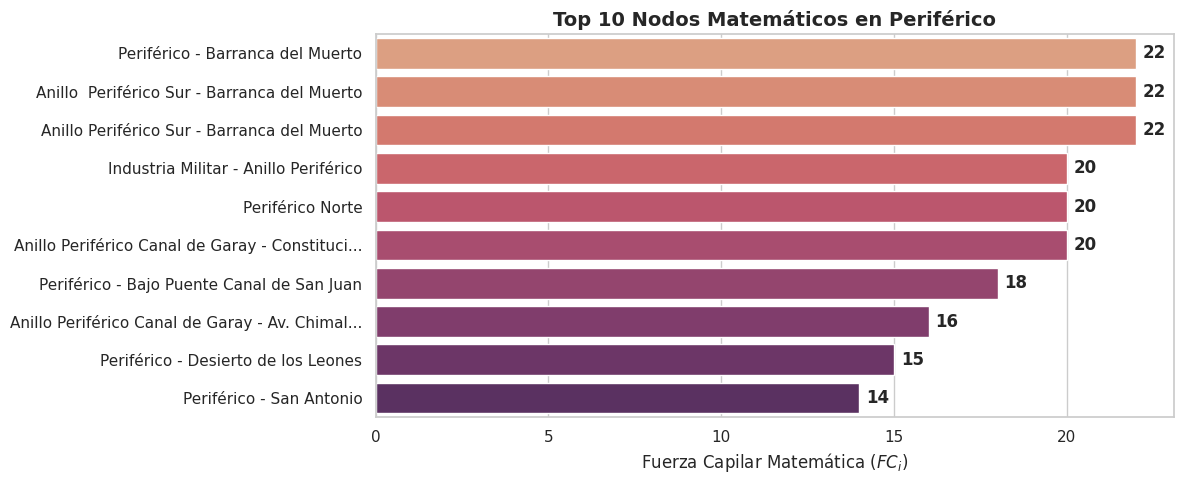

In [36]:
# --- Datos ---
top_peri_math = df_peri_math.head(10).copy()
top_peri_math['Estacion_Corta'] = top_peri_math['Estacion'].apply(
    lambda x: x[:45] + '...' if len(x) > 45 else x
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=top_peri_math, 
    x='Fuerza_Capilar_Total', 
    y='Estacion_Corta', 
    palette='flare', 
    ax=ax
)

ax.set_title('Top 10 Nodos Matemáticos en Periférico', fontsize=14, fontweight='bold')
ax.set_xlabel('Fuerza Capilar Matemática ($FC_i$)')
ax.set_ylabel('')

for i in ax.containers:
    ax.bar_label(i, padding=5, fontweight='bold')

plt.tight_layout()
display(fig)
plt.close(fig)

In [37]:
# Mapa
mapa_peri_math = folium.Map(location=[19.3500, -99.1900], zoom_start=11, tiles="CartoDB positron")
for _, row in top_peri_math.iterrows():
    try:
        lon, lat = ast.literal_eval(row['Nodo_ID'])
        folium.CircleMarker(
            location=(lat, lon), radius=max(row['Fuerza_Capilar_Total']*0.3, 6),
            color="#E67E22", fill=True, fill_opacity=0.8, popup=f"Nodo: {row['Estacion_Corta']}"
        ).add_to(mapa_peri_math)
    except: pass
display(mapa_peri_math)

---
**Nota Aclaratoria:** *Los mapas mostrados en la Sección 7 representan únicamente una evaluación de la infraestructura preexistente. Aún no se traza ni se mapea el recorrido geométrico propuesto para el "Corredor Anillar", por lo que esta sección se mantiene en un plano puramente especulativo para identificar los puntos naturales de anclaje de la futura línea.*